# 2주차. 객체지향 프로그래밍과 시각화

| 항목 | 내용 |
|---|---|
| 이름 | 이성민 |
| 학과 | 소프트웨어융합과 |
| 학년 | 2학년 |
| 학번 | 2151050 |

이 노트북은 수업 주차 흐름을 참고해 우리 방식으로 재구성한 실행형 설명 자료입니다. 외부 서비스 호출 없이 실행되도록 작은 샘플 데이터를 사용합니다.

## 클래스 설계
클래스는 데이터와 행동을 한 단위로 묶습니다. 캐릭터 객체를 만들면 상태 변화와 행동 로그를 같은 인터페이스로 관리할 수 있습니다.

In [1]:
from dataclasses import dataclass, field
import random
import pandas as pd
import matplotlib.pyplot as plt

random.seed(2151050)

@dataclass
class Character:
    name: str
    role: str
    energy: int = 100
    score: int = 0
    log: list[str] = field(default_factory=list)

    def action(self, verb, point):
        self.energy = max(0, self.energy - random.randint(3, 10))
        self.score += point
        self.log.append(verb)
        return {"name": self.name, "action": verb, "energy": self.energy, "score": self.score}

tom = Character("Tom", "cat")
jerry = Character("Jerry", "mouse")
rows = [
    tom.action("chase", 2),
    jerry.action("escape", 3),
    tom.action("wait", 0),
    jerry.action("trick", 4),
]
result = pd.DataFrame(rows)
display(result)

,name,action,energy,score
0,Tom,chase,90,2
1,Jerry,escape,93,3
2,Tom,wait,82,2
3,Jerry,trick,84,7


## 시각화
객체의 상태도 표로 바꾸면 그래프로 비교할 수 있습니다. 객체지향 코드와 데이터 분석 코드는 서로 보완적으로 사용할 수 있습니다.

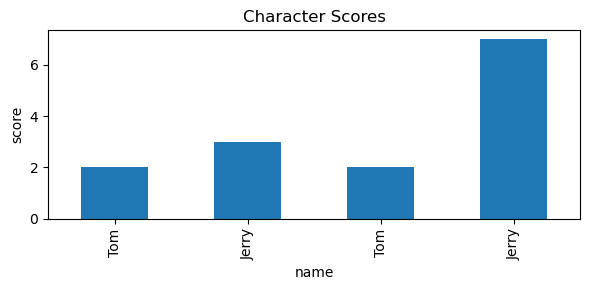

In [2]:
ax = result.plot(kind="bar", x="name", y="score", legend=False, title="Character Scores", figsize=(6, 3))
ax.set_ylabel("score")
plt.tight_layout()
plt.show()

assert result["energy"].between(0, 100).all()
assert set(result["name"]) == {"Tom", "Jerry"}